# Analysis of Found Pieces & Guitarburst Dataset

This notebook performs analysis on two datasets:
1. `found_pieces.xlsx`: Analysis of validation categories (`validated`) and their associated difficulty distributions.
2. `guitarburst_full.json`: Analysis of overall difficulty distributions in the complete Guitarburst dataset.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for premium aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']

# Find and load the Excel file robustly
excel_path = 'found_pieces.xlsx'
if not os.path.exists(excel_path):
    excel_path = 'features/found_pieces.xlsx'

print(f"Loading Excel data from: {excel_path}")
df_excel = pd.read_excel(excel_path)
print(f"Loaded {len(df_excel)} rows and {len(df_excel.columns)} columns successfully.")

Loading Excel data from: found_pieces.xlsx
Loaded 255 rows and 15 columns successfully.


## 1. Frequency Distribution of the First Column (`validated`)

Let's check the first column, calculate the count and percentage for each category, and visualize the distribution with a bar chart.

First column name: 'validated'

--- Frequency Table of Validation Categories ---


,Count,Percentage (%)
validated,,
?,162,63.53
(repeat),86,33.73
don’t wanna,5,1.96
NaN,1,0.39
,1,0.39


/tmp/ipykernel_256874/551761063.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


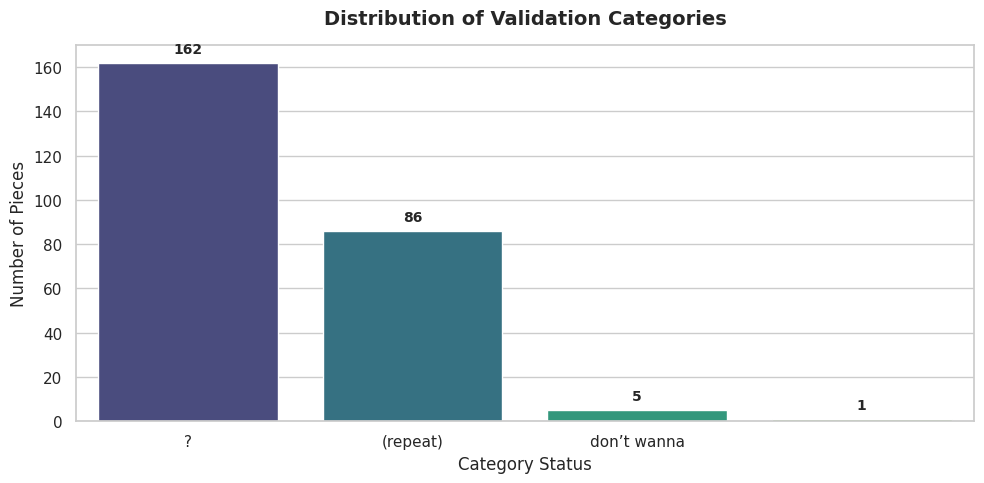

In [2]:
# Identify the first column name
first_col = df_excel.columns[0]
print(f"First column name: '{first_col}'\n")

# Compute value counts (including NaN values to see missing entries)
validation_counts = df_excel[first_col].value_counts(dropna=False)
validation_percentage = df_excel[first_col].value_counts(dropna=False, normalize=True) * 100

# Combine into a clean summary DataFrame
summary_df = pd.DataFrame({
    'Count': validation_counts,
    'Percentage (%)': validation_percentage.round(2)
})
print("--- Frequency Table of Validation Categories ---")
display(summary_df)

# Plot validation status counts
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df_excel, 
    x=first_col, 
    order=df_excel[first_col].value_counts().index,
    palette="viridis"
)
plt.title("Distribution of Validation Categories", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Category Status", fontsize=12)
plt.ylabel("Number of Pieces", fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Difficulty Distribution (Column D: `Difficulty`) - Excel Overall

Let's clean the column by converting non-numeric strings (like `'Error'`) to `NaN` and plot the overall histogram for the Excel file.

Difficulty column name: 'Difficulty'

Successfully parsed difficulty levels.
Total rows in Excel dataset: 255
Number of non-numeric/missing values (e.g., 'Error', NaN): 0

--- Descriptive Statistics for Difficulty Levels ---


count    255.000000
mean       7.529412
std        3.857465
min        1.000000
25%        5.000000
50%        7.000000
75%        9.000000
max       20.000000
Name: Difficulty_Cleaned, dtype: float64

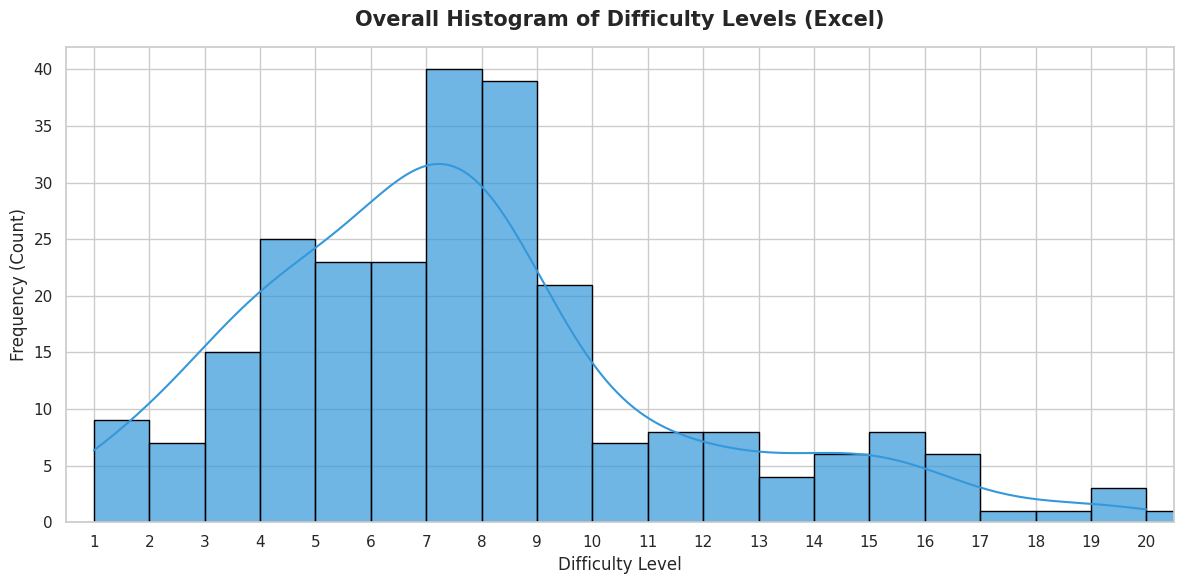

In [3]:
# Select the 4th column (Index 3, representing column D)
diff_col = df_excel.columns[3]
print(f"Difficulty column name: '{diff_col}'\n")

# Clean and convert to numeric, converting non-numeric to NaN
df_excel['Difficulty_Cleaned'] = pd.to_numeric(df_excel[diff_col], errors='coerce')

# Print summary of cleaned values
num_nans = df_excel['Difficulty_Cleaned'].isna().sum()
print(f"Successfully parsed difficulty levels.")
print(f"Total rows in Excel dataset: {len(df_excel)}")
print(f"Number of non-numeric/missing values (e.g., 'Error', NaN): {num_nans}")

# Display basic statistics for cleaned difficulties
print("\n--- Descriptive Statistics for Difficulty Levels ---")
display(df_excel['Difficulty_Cleaned'].describe())

# Plot histogram of difficulty levels
plt.figure(figsize=(12, 6))

# Use bins to align exactly with integer difficulty levels
min_diff = int(df_excel['Difficulty_Cleaned'].min()) if not pd.isna(df_excel['Difficulty_Cleaned'].min()) else 1
max_diff = int(df_excel['Difficulty_Cleaned'].max()) if not pd.isna(df_excel['Difficulty_Cleaned'].max()) else 20
bins = range(min_diff, max_diff + 2)

sns.histplot(
    data=df_excel,
    x='Difficulty_Cleaned',
    bins=bins,
    kde=True,
    color='#3498db',
    edgecolor='black',
    alpha=0.7
)

plt.title("Overall Histogram of Difficulty Levels (Excel)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Difficulty Level", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

# Ensure integer ticks on x-axis
plt.xticks(range(min_diff, max_diff + 1))
plt.xlim(min_diff - 0.5, max_diff + 0.5)

plt.tight_layout()
plt.show()

## 3. Difficulty Distribution for Each Category in the First Column (Excel)

Now we'll break down the difficulty levels in the Excel file by each category of the validation status (`validated`).

In [4]:
# Group by validation category and show descriptive stats for Difficulty
print("--- Difficulty Descriptive Statistics Grouped by Validation Category ---")
grouped_stats = df_excel.groupby(first_col)['Difficulty_Cleaned'].describe()
display(grouped_stats)

--- Difficulty Descriptive Statistics Grouped by Validation Category ---


,count,mean,std,min,25%,50%,75%,max
validated,,,,,,,,
,1.0,9.000000,NaN,9.0,9.0,9.0,9.0,9.0
(repeat),86.0,7.360465,3.697098,1.0,5.0,7.0,9.0,19.0
?,162.0,7.660494,3.901208,1.0,5.0,7.0,9.0,20.0
don’t wanna,5.0,5.800000,6.016644,1.0,2.0,4.0,6.0,16.0


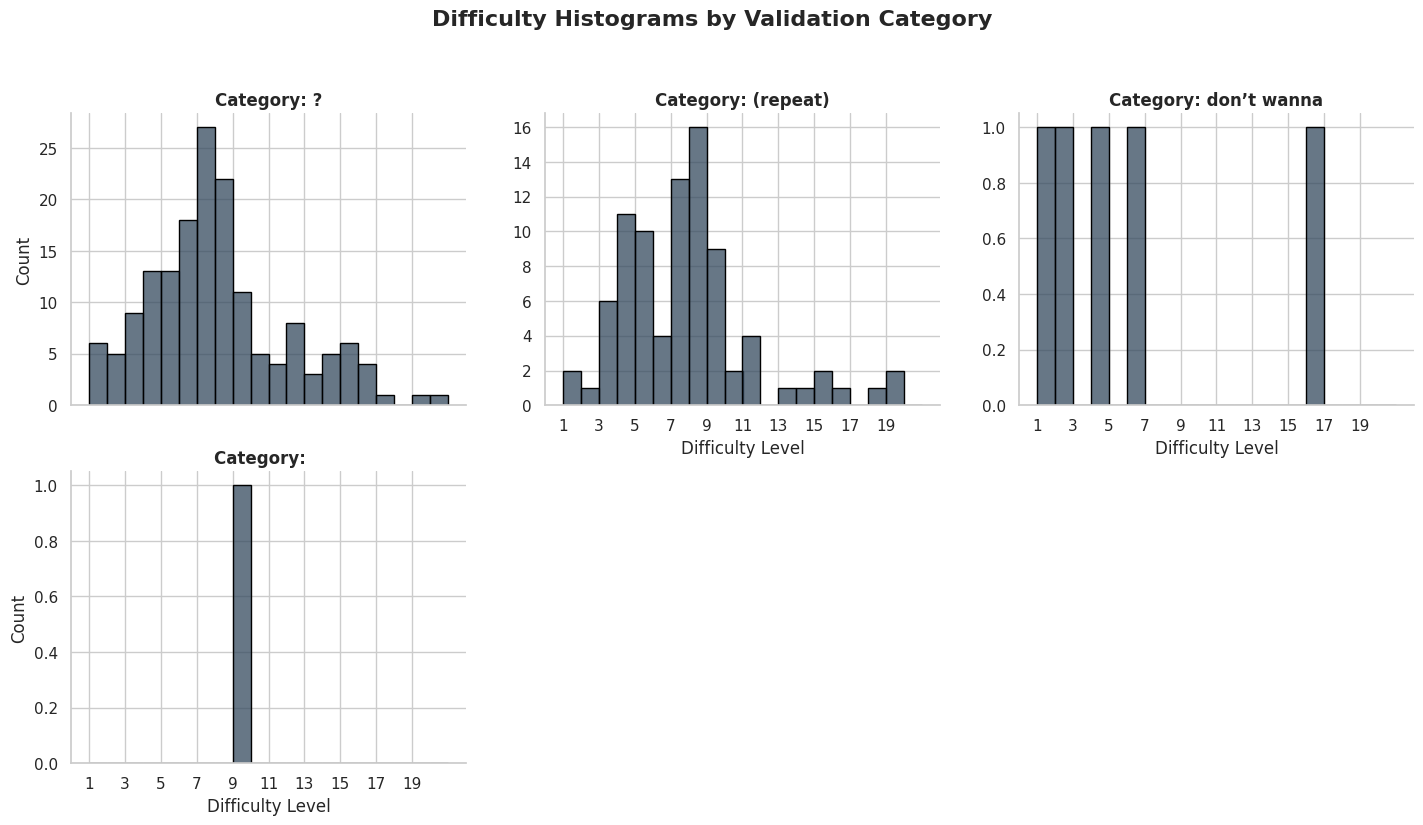

In [5]:
# Filter out rows where validation or difficulty is missing for plotting
plot_df = df_excel.dropna(subset=[first_col, 'Difficulty_Cleaned']).copy()
plot_df[first_col] = plot_df[first_col].astype(str)

# Create faceted histograms using seaborn FacetGrid
min_diff = int(plot_df['Difficulty_Cleaned'].min())
max_diff = int(plot_df['Difficulty_Cleaned'].max())
bins = range(min_diff, max_diff + 2)

g = sns.FacetGrid(
    plot_df, 
    col=first_col, 
    col_wrap=3, 
    height=4, 
    aspect=1.2, 
    sharey=False  # Allow individual y-axis scaling since sample sizes vary significantly
)
g.map(sns.histplot, 'Difficulty_Cleaned', bins=bins, color='#34495e', edgecolor='black', alpha=0.75)

g.set_titles("Category: {col_name}", size=12, weight='bold')
g.set_axis_labels("Difficulty Level", "Count")

# Set ticks for each subplot
for ax in g.axes.flat:
    ax.set_xticks(range(min_diff, max_diff + 1, 2))

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Difficulty Histograms by Validation Category", fontsize=16, fontweight='bold', y=1.03)
plt.show()

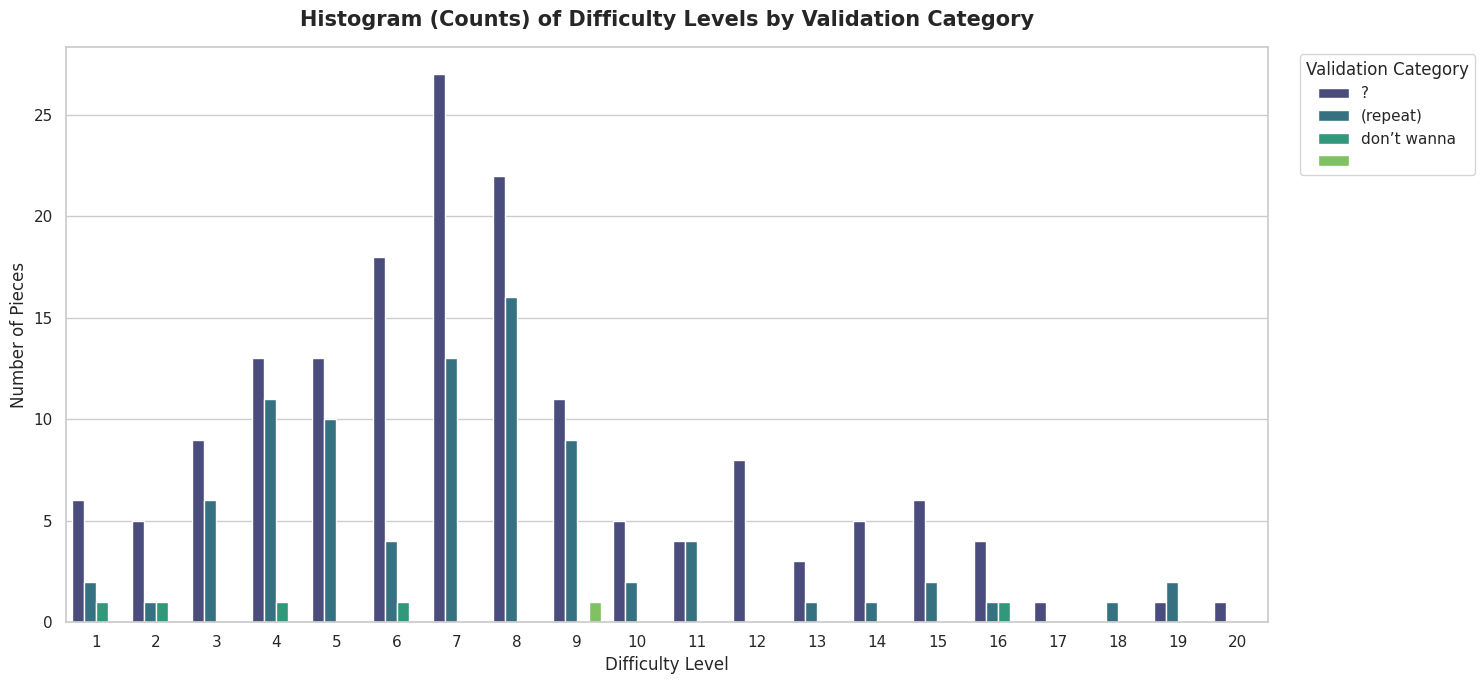

In [6]:
# Grouped Countplot (Histogram) showing the number of pieces per difficulty level, color-coded by validation category
plt.figure(figsize=(15, 7))

# Order validation status categories by their overall frequency
category_order = plot_df[first_col].value_counts().index

sns.countplot(
    data=plot_df,
    x='Difficulty_Cleaned',
    hue=first_col,
    hue_order=category_order,
    palette="viridis"
)

plt.title("Histogram (Counts) of Difficulty Levels by Validation Category", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Difficulty Level", fontsize=12)
plt.ylabel("Number of Pieces", fontsize=12)
plt.legend(title="Validation Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Difficulty Distribution in Guitarburst Full JSON (`guitarburst_full.json`)

We will load the full `guitarburst_full.json` dataset and analyze its overall difficulty distribution.

In [7]:
# Find and load the JSON file robustly
json_path = 'guitarburst_full.json'
if not os.path.exists(json_path):
    json_path = 'features/guitarburst_full.json'

print(f"Loading JSON data from: {json_path}")
with open(json_path, 'r') as f:
    json_data = json.load(f)

df_json = pd.DataFrame(json_data)
print(f"Loaded {len(df_json)} rows and {len(df_json.columns)} columns successfully.")

# Clean and convert Difficulty to numeric
df_json['Difficulty_Cleaned'] = pd.to_numeric(df_json['Difficulty'], errors='coerce')
num_nans_json = df_json['Difficulty_Cleaned'].isna().sum()

print(f"\nNumber of non-numeric/missing difficulty values: {num_nans_json}")
print("\n--- Descriptive Statistics for Difficulty in Guitarburst Full JSON ---")
display(df_json['Difficulty_Cleaned'].describe())

Loading JSON data from: guitarburst_full.json
Loaded 2335 rows and 14 columns successfully.

Number of non-numeric/missing difficulty values: 0

--- Descriptive Statistics for Difficulty in Guitarburst Full JSON ---


count    2335.000000
mean        7.547752
std         4.367463
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        20.000000
Name: Difficulty_Cleaned, dtype: float64

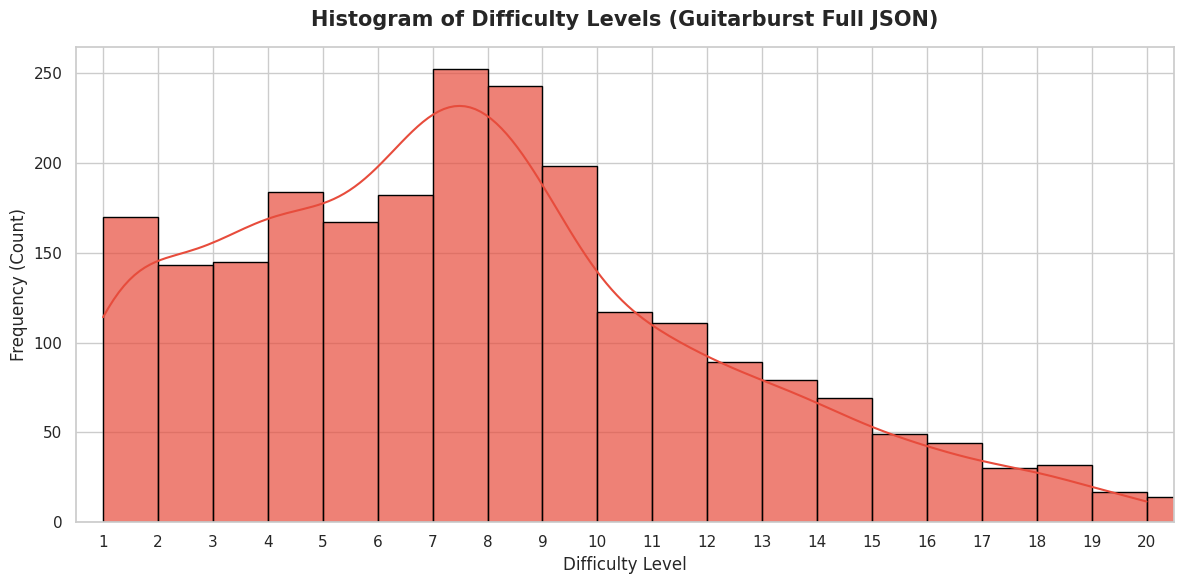

In [8]:
# Plot histogram of difficulty levels in the JSON dataset
plt.figure(figsize=(12, 6))

min_diff_json = int(df_json['Difficulty_Cleaned'].min()) if not pd.isna(df_json['Difficulty_Cleaned'].min()) else 1
max_diff_json = int(df_json['Difficulty_Cleaned'].max()) if not pd.isna(df_json['Difficulty_Cleaned'].max()) else 20
bins_json = range(min_diff_json, max_diff_json + 2)

sns.histplot(
    data=df_json,
    x='Difficulty_Cleaned',
    bins=bins_json,
    kde=True,
    color='#e74c3c',  # Red color for contrast with the excel histogram
    edgecolor='black',
    alpha=0.7
)

plt.title("Histogram of Difficulty Levels (Guitarburst Full JSON)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Difficulty Level", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

# Ensure integer ticks on x-axis
plt.xticks(range(min_diff_json, max_diff_json + 1))
plt.xlim(min_diff_json - 0.5, max_diff_json + 0.5)

plt.tight_layout()
plt.show()